<a href="https://colab.research.google.com/github/nascimentomacedodani487-hue/bank-churn-prediction/blob/main/bank_churn_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 📊 Customer Churn Prediction & Retention Strategy (Banking Dataset)
### Previsão de evasão de clientes em instituições financeiras **bold text**

In [1]:
!pip install pandas numpy matplotlib seaborn scikit-learn

**IMPORTAÇÕES**

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

**UPLOAD DO ARQUIVO**

In [3]:
from google.colab import files
uploaded = files.upload()

Saving Customer-Churn-Records.csv to Customer-Churn-Records (3).csv


**CARREGAMENTO DO ARQUIVO**

In [4]:
df = pd.read_csv("Customer-Churn-Records.csv")
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Complain,Satisfaction Score,Card Type,Point Earned
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1,1,2,DIAMOND,464
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0,1,3,DIAMOND,456
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1,1,3,DIAMOND,377
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0,0,5,GOLD,350
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0,0,5,GOLD,425


In [5]:
from google.colab import sheets
sheet = sheets.InteractiveSheet(df=df)

https://docs.google.com/spreadsheets/d/1g9SPD43T8yOn3VvBA0Au5iGs5PkDNukiJKlnEZfvSLY/edit#gid=0


In [6]:
df.dtypes


,0
RowNumber,int64
CustomerId,int64
Surname,object
CreditScore,int64
Geography,object
Gender,object
Age,int64
Tenure,int64
Balance,float64
NumOfProducts,int64


**QUANTIDADE DE CLIENTES POR GÊNERO**

In [7]:
df['Geography'].value_counts()
df['Gender'].value_counts()

,count
Gender,
Male,5457
Female,4543


**PORCENTAGEM DE CLIENTES ATIVOS E INATIVOS**

In [8]:
df['Exited'].value_counts(normalize=True) * 100

,proportion
Exited,
0,79.62
1,20.38


**TAXA DE CHURN**

In [9]:
df['Exited'].mean()

np.float64(0.2038)

**PERFIL DE QUEM SAI**

In [10]:
df.groupby('Exited')['Age'].mean()
df.groupby('Exited')['Balance'].mean()
df.groupby('Exited')['NumOfProducts'].mean()

,NumOfProducts
Exited,
0,1.544210
1,1.475466


**GEOGRAFIA POR PAÍSES**

In [11]:
pd.crosstab(df['Geography'], df['Exited'], normalize='index')

Exited,0,1
Geography,,
France,0.838253,0.161747
Germany,0.675568,0.324432
Spain,0.833266,0.166734


**ATIVIDADE DO CLIENTE**

In [12]:
pd.crosstab(df['IsActiveMember'], df['Exited'])

Exited,0,1
IsActiveMember,,
0,3546,1303
1,4416,735


**RECLAMAÇÃO VS. CHURN**

**Clientes que apresentaram reclamações possuem maior probabilidade de churn, indicando que falhas na experiência do cliente impactam diretamente na retenção**

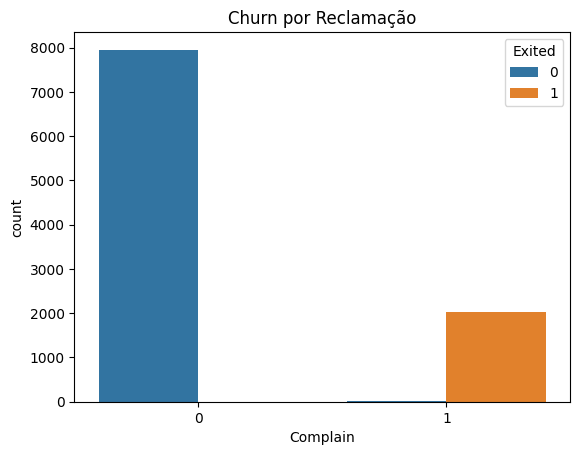

In [13]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='Complain', hue='Exited', data=df)
plt.title('Churn por Reclamação')
plt.show()

**Atividade vs Churn**

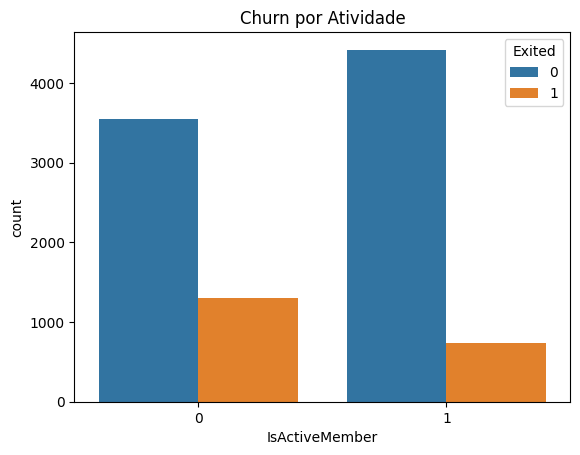

In [14]:
sns.countplot(x='IsActiveMember', hue='Exited', data=df)
plt.title('Churn por Atividade')
plt.show()

**Idade vs Churn**

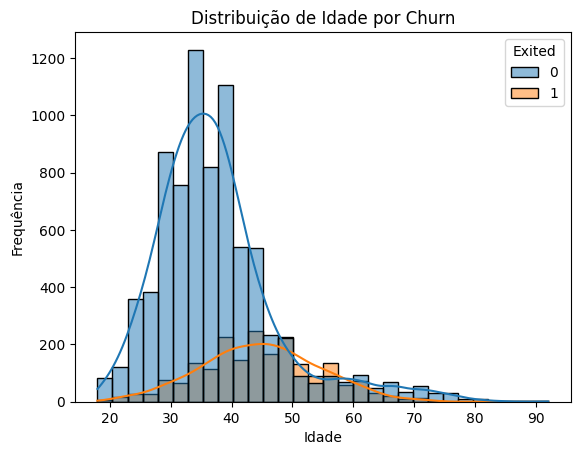

In [15]:
sns.histplot(data=df, x='Age', hue='Exited', kde=True, bins=30)
plt.title('Distribuição de Idade por Churn')
plt.xlabel('Idade')
plt.ylabel('Frequência')
plt.show()

**QUANTIDADE DE CLIENTES QUE SAEM POR QUANTIDADE DE PRODUTOS**

In [16]:
pd.crosstab(df['NumOfProducts'], df['Exited'], normalize='index') * 100

Exited,0,1
NumOfProducts,,
1,72.285602,27.714398
2,92.396514,7.603486
3,17.293233,82.706767
4,0.000000,100.000000


**MODELO PREDITIVO**

In [17]:
df = pd.read_csv('/content/Customer-Churn-Records.csv')
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Complain,Satisfaction Score,Card Type,Point Earned
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1,1,2,DIAMOND,464
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0,1,3,DIAMOND,456
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1,1,3,DIAMOND,377
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0,0,5,GOLD,350
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0,0,5,GOLD,425


**DATA CLEANING**

In [18]:
df_model = df.drop(['RowNumber', 'CustomerId', 'Surname', 'Complain', 'Satisfaction Score'], axis=1)

**TRANSFORMANDO CATEGORICAS ONE-HOT ENCODING**

In [19]:
df_model = pd.get_dummies(df_model, drop_first=True)

**SEPARAR FEATURES E TARGET**

In [20]:
X = df_model.drop('Exited', axis=1)
y = df_model['Exited']

**TREINO E TESTE**

In [21]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# separação
X = df_model.drop('Exited', axis=1)
y = df_model['Exited']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# ESCALA (ESSENCIAL)
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

**TREINANDO MODELO**

In [22]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=2000)
model.fit(X_train, y_train)

LogisticRegression(max_iter=2000)

**PREVISÃO**

In [23]:
y_pred = model.predict(X_test)

**MÉTRICAS RANDOM FOREST**

In [24]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier()
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

In [25]:
from sklearn.metrics import classification_report, confusion_matrix

print(confusion_matrix(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))

[[1551   56]
 [ 215  178]]
              precision    recall  f1-score   support

           0       0.88      0.97      0.92      1607
           1       0.76      0.45      0.57       393

    accuracy                           0.86      2000
   macro avg       0.82      0.71      0.74      2000
weighted avg       0.86      0.86      0.85      2000



In [26]:
df.corr(numeric_only=True)['Exited'].sort_values(ascending=False)

,Exited
Exited,1.000000
Complain,0.995693
Age,0.285296
Balance,0.118577
EstimatedSalary,0.012490
Point Earned,-0.004628
Satisfaction Score,-0.005849
CustomerId,-0.006203
HasCrCard,-0.006976
Tenure,-0.013656


In [27]:
df_model = df.drop([
    'RowNumber',
    'CustomerId',
    'Surname',
    'Complain',
    'Satisfaction Score'
], axis=1)

In [28]:
from sklearn.metrics import classification_report, confusion_matrix

print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

[[1541   66]
 [ 314   79]]
              precision    recall  f1-score   support

           0       0.83      0.96      0.89      1607
           1       0.54      0.20      0.29       393

    accuracy                           0.81      2000
   macro avg       0.69      0.58      0.59      2000
weighted avg       0.77      0.81      0.77      2000



**MATRIZ DE CONFUSÃO**

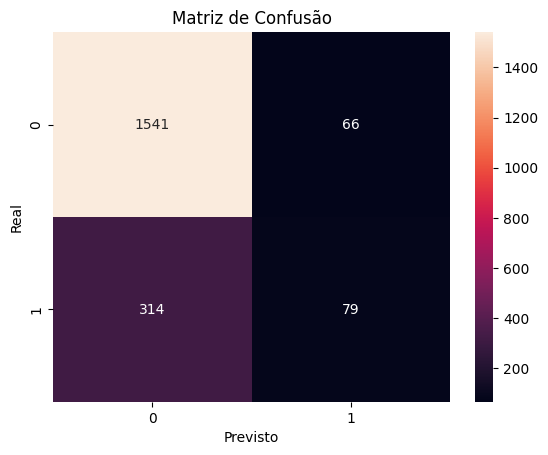

In [29]:
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d')
plt.title('Matriz de Confusão')
plt.xlabel('Previsto')
plt.ylabel('Real')
plt.show()

**IMPORTÂNCIA DAS VÁRIAVEIS**

In [30]:
importance = pd.Series(model.coef_[0], index=X.columns)
importance = importance.sort_values(ascending=False)

importance.head(10)

,0
Age,0.756827
Geography_Germany,0.337565
Balance,0.160728
Geography_Spain,0.037816
EstimatedSalary,0.018733
HasCrCard,-0.011403
Card Type_SILVER,-0.022945
Card Type_PLATINUM,-0.041072
Tenure,-0.041080
Point Earned,-0.046494


**GRÁFICO DAS IMPORTÂNCIAS**

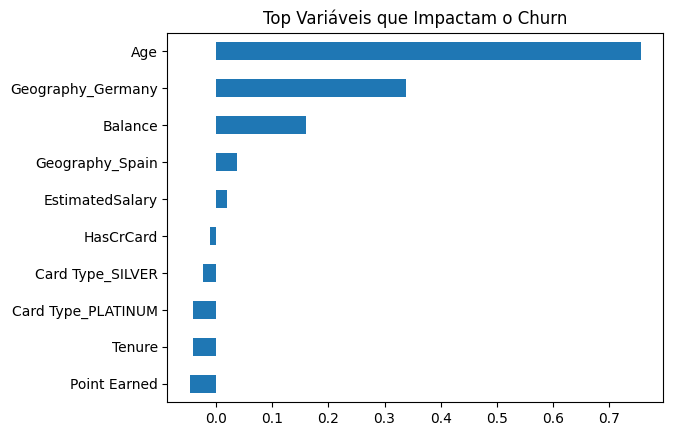

In [31]:
importance.head(10).plot(kind='barh')
plt.title('Top Variáveis que Impactam o Churn')
plt.gca().invert_yaxis()
plt.show()